## Imports and paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (precision_score,  recall_score,  roc_auc_score,  accuracy_score,  f1_score,  confusion_matrix,  roc_curve )

## 1. Modeling preparation

In [2]:
DATA_DIR = Path("../Cleaned Data/Splits")  # Training and test set folder
RANDOM_STATE = 1948883                     # Using My ID as a random seed, make the results reproducible.
N_SPLITS = 5                               # 5-fold cross-validation
N_ITER_SEARCH = 40                         # Number of random hyperparameter combinations tested in RandomizedSearchCV.
TOP_N_FEATURES = 15                        # Number of most important features to display in feature-importance plots.


# 4 modeling tasks
TASKS ={
    "before_mask": "Before mandate - Face mask",                    # 1. Face mask behavior prediction before mask mandate
    "after_mask": "After mandate - Face mask",                      # 2. Face mask behavior prediction after mask mandate
    "before_protective": "Before mandate - Protective behaviour",   # 3. Protective behavior prediction before mask mandate
    "after_protective": "After mandate - Protective behaviour",     # 4. Protective behavior prediction after mask mandate
}


# Evaluation indicators
METRICS = ["precision", "recall", "roc_auc", "accuracy", "f1"]


## 2. Define Model

In [3]:
# Read the corresponding training and test sets based on the task name.
def load_task(task):
    X_train = pd.read_csv(DATA_DIR / f"X_train_{task}.csv")
    X_test = pd.read_csv(DATA_DIR / f"X_test_{task}.csv")
    y_train = pd.read_csv(DATA_DIR / f"y_train_{task}.csv").iloc[:, 0].astype(int)
    y_test = pd.read_csv(DATA_DIR / f"y_test_{task}.csv").iloc[:, 0].astype(int)
    return X_train, X_test, y_train, y_test


# Build the Classification Tree pipeline.
# RandomOverSampler is included inside the pipeline so that oversampling is applied only to the training folds.
def build_pipeline():
    return Pipeline(steps=[
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ])


# Hyperparameter search space for the Classification Tree.
def get_param_distributions():
    return {
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [3, 5, 8, 10, 12, 15, 20, None],
        "model__min_samples_split": [2, 5, 10, 20, 30, 50],
        "model__min_samples_leaf": [1, 2, 5, 10, 20],
        "model__min_impurity_decrease": [0.0, 0.0001, 0.001, 0.005, 0.01],
    }


# Build RandomizedSearchCV for hyperparameter tuning.
def build_search():
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        estimator=build_pipeline(),
        param_distributions=get_param_distributions(),
        n_iter=N_ITER_SEARCH,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
        verbose=0,
        return_train_score=False,
    )
    return search


# Calculate evaluation indicators.
def get_metrics(y_true, y_pred, y_prob):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


# Save results.
results = {}                       # Detailed results for each task
cv_summary = []                    # Average cross-validation result for each task
test_summary = []                  # Final results on the test set
search_summary = []                # search summary

## 3. Model training and prediction

In [4]:
# Perform Classification Tree modeling on the 4 tasks.

for task, label in TASKS.items():
    X_train, X_test, y_train, y_test = load_task(task)

    # Use 5-fold cross-validation inside RandomizedSearchCV to find the best hyperparameters.
    search = build_search()
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_params = search.best_params_
    best_cv_auc = search.best_score_

    # Save hyperparameter search results.
    cv_results_df = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")

    search_row = {
        "task": task,
        "label": label,
        "best_cv_auc": best_cv_auc,
        **best_params
    }
    search_summary.append(search_row)

    # Use the best hyperparameters to calculate fold-level cross-validation metrics.
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    cv_rows = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        fold_model = build_pipeline()
        fold_model.set_params(**best_params)
        fold_model.fit(X_tr, y_tr)

        y_val_pred = fold_model.predict(X_val)
        y_val_prob = fold_model.predict_proba(X_val)[:, 1]

        row = get_metrics(y_val, y_val_pred, y_val_prob)
        row["fold"] = fold
        cv_rows.append(row)

    # Organize the results of all folds into a DataFrame.
    cv_df = pd.DataFrame(cv_rows)

    # Calculate the average cross-validation performance.
    cv_mean = cv_df[METRICS].mean().to_dict()
    cv_mean["task"] = task
    cv_mean["label"] = label
    cv_summary.append(cv_mean)

    # Predict on the final test set using the best model refitted by RandomizedSearchCV.
    y_test_pred = best_model.predict(X_test)
    y_test_prob = best_model.predict_proba(X_test)[:, 1]

    # Calculate test set evaluation indicators.
    test_row = get_metrics(y_test, y_test_pred, y_test_prob)
    test_row["task"] = task
    test_row["label"] = label
    test_summary.append(test_row)

    # Save feature importance.
    fitted_tree = best_model.named_steps["model"]

    importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": fitted_tree.feature_importances_
    }).sort_values("importance", ascending=False)

    # Save all important results.
    results[task] = {
        "label": label,
        "best_model": best_model,
        "best_params": best_params,
        "best_cv_auc": best_cv_auc,
        "cv_df": cv_df,
        "cv_results_df": cv_results_df,
        "test_metrics": test_row,
        "y_test": y_test,
        "y_test_pred": y_test_pred,
        "y_test_prob": y_test_prob,
        "importance_df": importance_df,
        "cm": confusion_matrix(y_test, y_test_pred)
    }


## 4. Results

### 4.1 Cross-validation average

In [5]:
cv_summary_df = pd.DataFrame(cv_summary)[["task", "label"] + METRICS]

print("CV mean results")
display(cv_summary_df.round(4))

CV mean results


,task,label,precision,recall,roc_auc,accuracy,f1
0,before_mask,Before mandate - Face mask,0.5165,0.7359,0.8187,0.7335,0.6069
1,after_mask,After mandate - Face mask,0.8832,0.8627,0.8595,0.8228,0.8728
2,before_protective,Before mandate - Protective behaviour,0.6673,0.7063,0.7401,0.6815,0.6857
3,after_protective,After mandate - Protective behaviour,0.8613,0.6919,0.7910,0.7069,0.7661


### 4.2 Final test set results


In [6]:
test_summary_df = pd.DataFrame(test_summary)[["task", "label"] + METRICS]

print("Test results")
display(test_summary_df.round(4))

Test results


,task,label,precision,recall,roc_auc,accuracy,f1
0,before_mask,Before mandate - Face mask,0.5461,0.7451,0.8297,0.7555,0.6303
1,after_mask,After mandate - Face mask,0.8901,0.8646,0.8688,0.8294,0.8771
2,before_protective,Before mandate - Protective behaviour,0.6631,0.6902,0.7341,0.6746,0.6764
3,after_protective,After mandate - Protective behaviour,0.8390,0.7534,0.7929,0.7274,0.7939


### 4.3 Best hyperparameters


In [7]:
search_summary_df = pd.DataFrame(search_summary)

print("Best hyperparameters selected by RandomizedSearchCV")
display(search_summary_df.round(6))


Best hyperparameters selected by RandomizedSearchCV


,task,label,best_cv_auc,model__min_samples_split,model__min_samples_leaf,model__min_impurity_decrease,model__max_depth,model__criterion
0,before_mask,Before mandate - Face mask,0.818699,30,1,0.0010,12,gini
1,after_mask,After mandate - Face mask,0.859472,50,20,0.0001,8,entropy
2,before_protective,Before mandate - Protective behaviour,0.740091,10,1,0.0010,5,entropy
3,after_protective,After mandate - Protective behaviour,0.791014,5,1,0.0010,12,entropy


### 4.4 Top search results


In [8]:
show_cols = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "param_model__criterion",
    "param_model__max_depth",
    "param_model__min_samples_split",
    "param_model__min_samples_leaf",
    "param_model__min_impurity_decrease"
]

for task, label in TASKS.items():
    print(label)
    display(results[task]["cv_results_df"][show_cols].head(10).round(6))


Before mandate - Face mask


,rank_test_score,mean_test_score,std_test_score,param_model__criterion,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__min_impurity_decrease
21,1,0.818699,0.013596,gini,12,30,1,0.0010
35,1,0.818699,0.013596,gini,None,10,1,0.0010
7,3,0.815785,0.012578,gini,5,2,1,0.0000
23,4,0.815767,0.012591,entropy,5,10,1,0.0010
0,5,0.814357,0.010852,gini,8,50,20,0.0001
2,6,0.813230,0.009210,entropy,8,50,20,0.0001
38,7,0.812022,0.010295,entropy,15,50,2,0.0010
4,8,0.810827,0.010150,entropy,8,30,20,0.0001
29,9,0.810824,0.010166,entropy,8,5,20,0.0000
26,10,0.810256,0.009470,entropy,12,5,1,0.0010


After mandate - Face mask


,rank_test_score,mean_test_score,std_test_score,param_model__criterion,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__min_impurity_decrease
2,1,0.859472,0.005209,entropy,8,50,20,0.0001
29,2,0.859091,0.005186,entropy,8,5,20,0.0000
38,3,0.858981,0.005295,entropy,15,50,2,0.0010
4,4,0.858954,0.005388,entropy,8,30,20,0.0001
26,5,0.858930,0.005286,entropy,12,5,1,0.0010
0,6,0.857912,0.003906,gini,8,50,20,0.0001
35,7,0.852245,0.007099,gini,None,10,1,0.0010
21,7,0.852245,0.007099,gini,12,30,1,0.0010
15,9,0.848636,0.005693,gini,20,5,20,0.0000
13,10,0.848470,0.005567,gini,None,30,20,0.0000


Before mandate - Protective behaviour


,rank_test_score,mean_test_score,std_test_score,param_model__criterion,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__min_impurity_decrease
23,1,0.740091,0.011165,entropy,5,10,1,0.0010
7,2,0.739357,0.010647,gini,5,2,1,0.0000
38,3,0.739247,0.014732,entropy,15,50,2,0.0010
26,4,0.738691,0.016154,entropy,12,5,1,0.0010
2,5,0.738322,0.010331,entropy,8,50,20,0.0001
4,6,0.736586,0.010385,entropy,8,30,20,0.0001
29,7,0.736544,0.010384,entropy,8,5,20,0.0000
0,8,0.735986,0.014137,gini,8,50,20,0.0001
35,9,0.734780,0.010684,gini,None,10,1,0.0010
21,9,0.734780,0.010684,gini,12,30,1,0.0010


After mandate - Protective behaviour


,rank_test_score,mean_test_score,std_test_score,param_model__criterion,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__min_impurity_decrease
26,1,0.791014,0.004126,entropy,12,5,1,0.0010
38,1,0.791014,0.004126,entropy,15,50,2,0.0010
4,3,0.789046,0.004949,entropy,8,30,20,0.0001
29,4,0.789012,0.004868,entropy,8,5,20,0.0000
2,5,0.788816,0.004987,entropy,8,50,20,0.0001
0,6,0.787739,0.005388,gini,8,50,20,0.0001
35,7,0.780848,0.003344,gini,None,10,1,0.0010
21,7,0.780848,0.003344,gini,12,30,1,0.0010
7,9,0.772488,0.004326,gini,5,2,1,0.0000
23,10,0.771325,0.003771,entropy,5,10,1,0.0010


### 4.5 Bar charts of various indicators


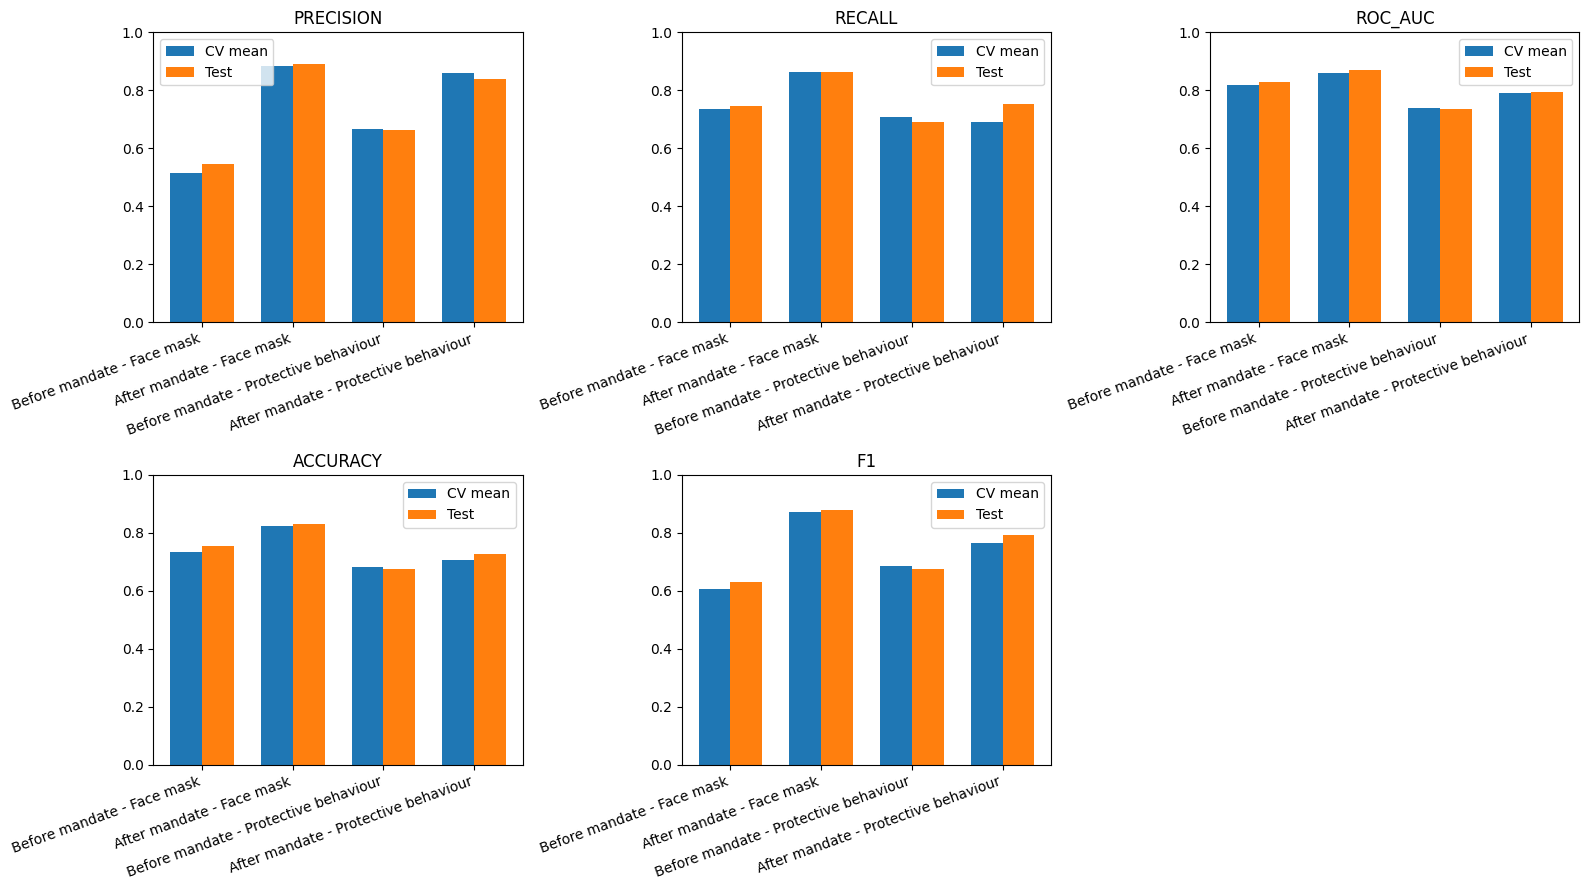

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, metric in enumerate(METRICS):
    ax = axes[i]

    cv_vals = cv_summary_df.set_index("task").loc[list(TASKS.keys()), metric]
    test_vals = test_summary_df.set_index("task").loc[list(TASKS.keys()), metric]

    x = np.arange(len(TASKS))
    width = 0.35

    ax.bar(x - width / 2, cv_vals.values, width=width, label="CV mean")
    ax.bar(x + width / 2, test_vals.values, width=width, label="Test")
    ax.set_xticks(x)
    ax.set_xticklabels(list(TASKS.values()), rotation=20, ha="right")
    ax.set_ylim(0, 1)
    ax.set_title(metric.upper())
    ax.legend()

axes[-1].axis("off")
plt.tight_layout()
plt.show()


### 4.6 ROC curve


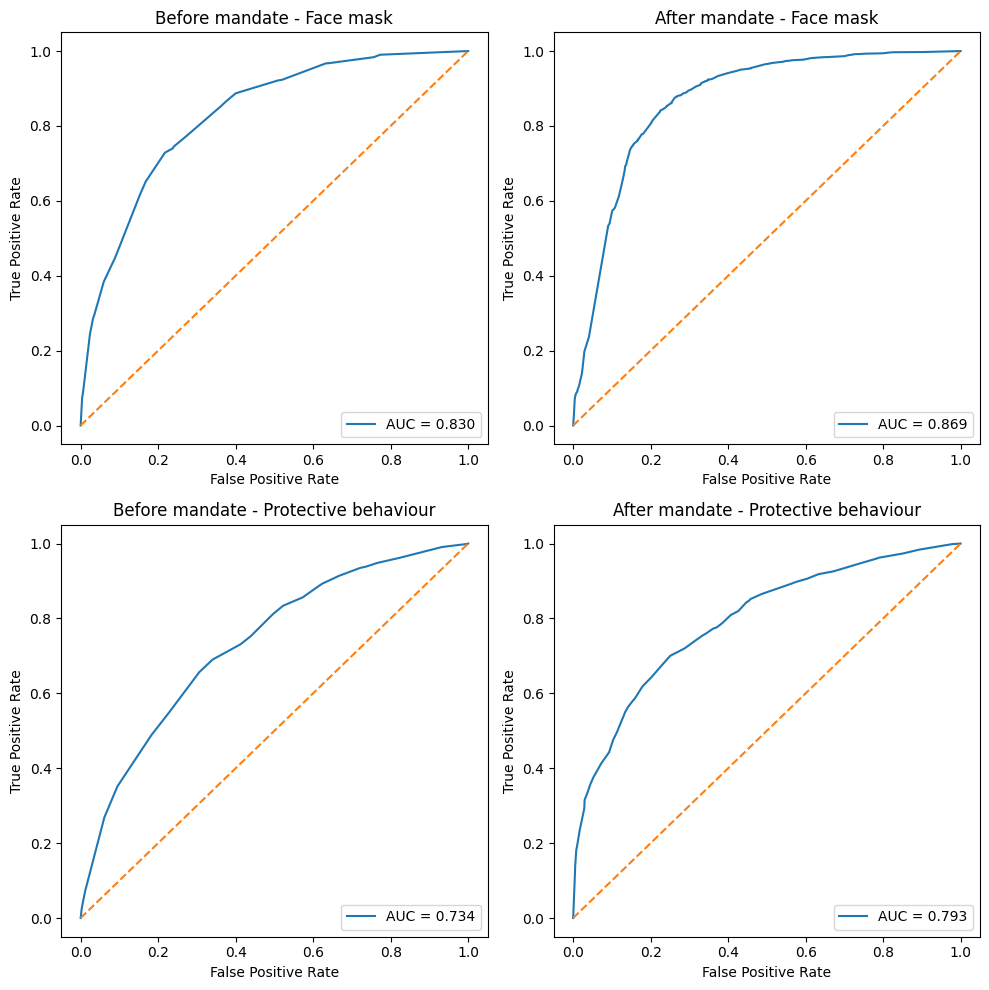

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, task in zip(axes, TASKS.keys()):
    y_test = results[task]["y_test"]
    y_prob = results[task]["y_test_prob"]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    ax.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(TASKS[task])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()


### 4.7 Confusion matrix heatmap


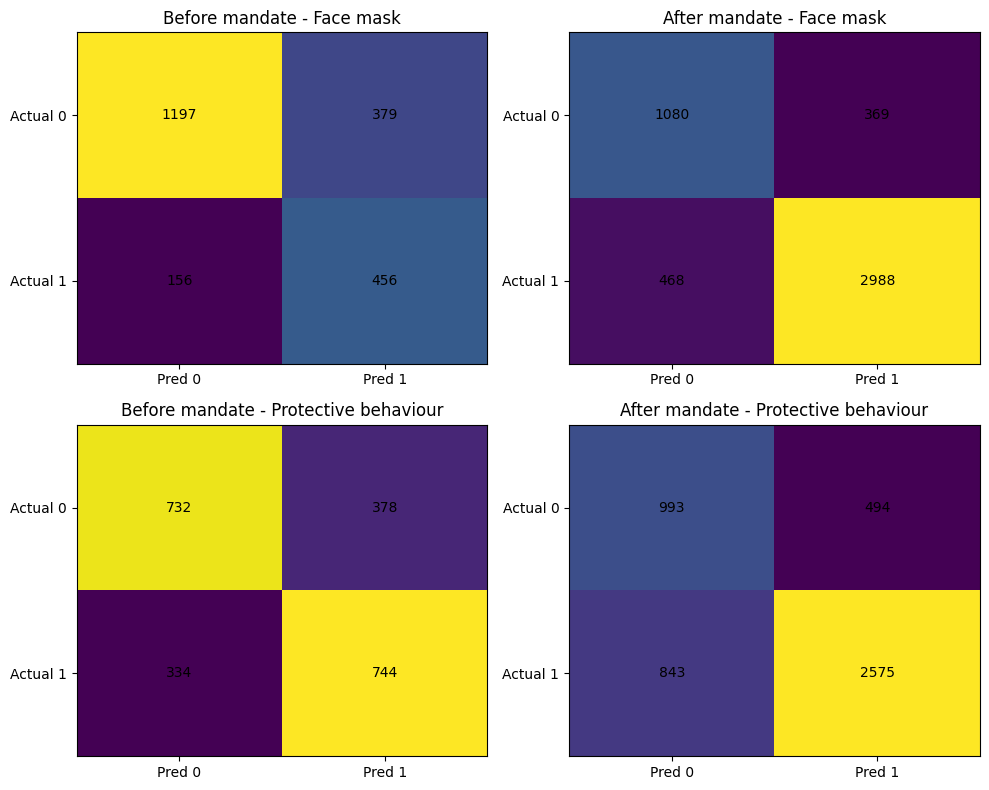

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, task in zip(axes, TASKS.keys()):
    cm = results[task]["cm"]

    ax.imshow(cm, aspect="auto")
    ax.set_title(TASKS[task])
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticklabels(["Actual 0", "Actual 1"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center")

plt.tight_layout()
plt.show()


### 4.8 Top feature importance


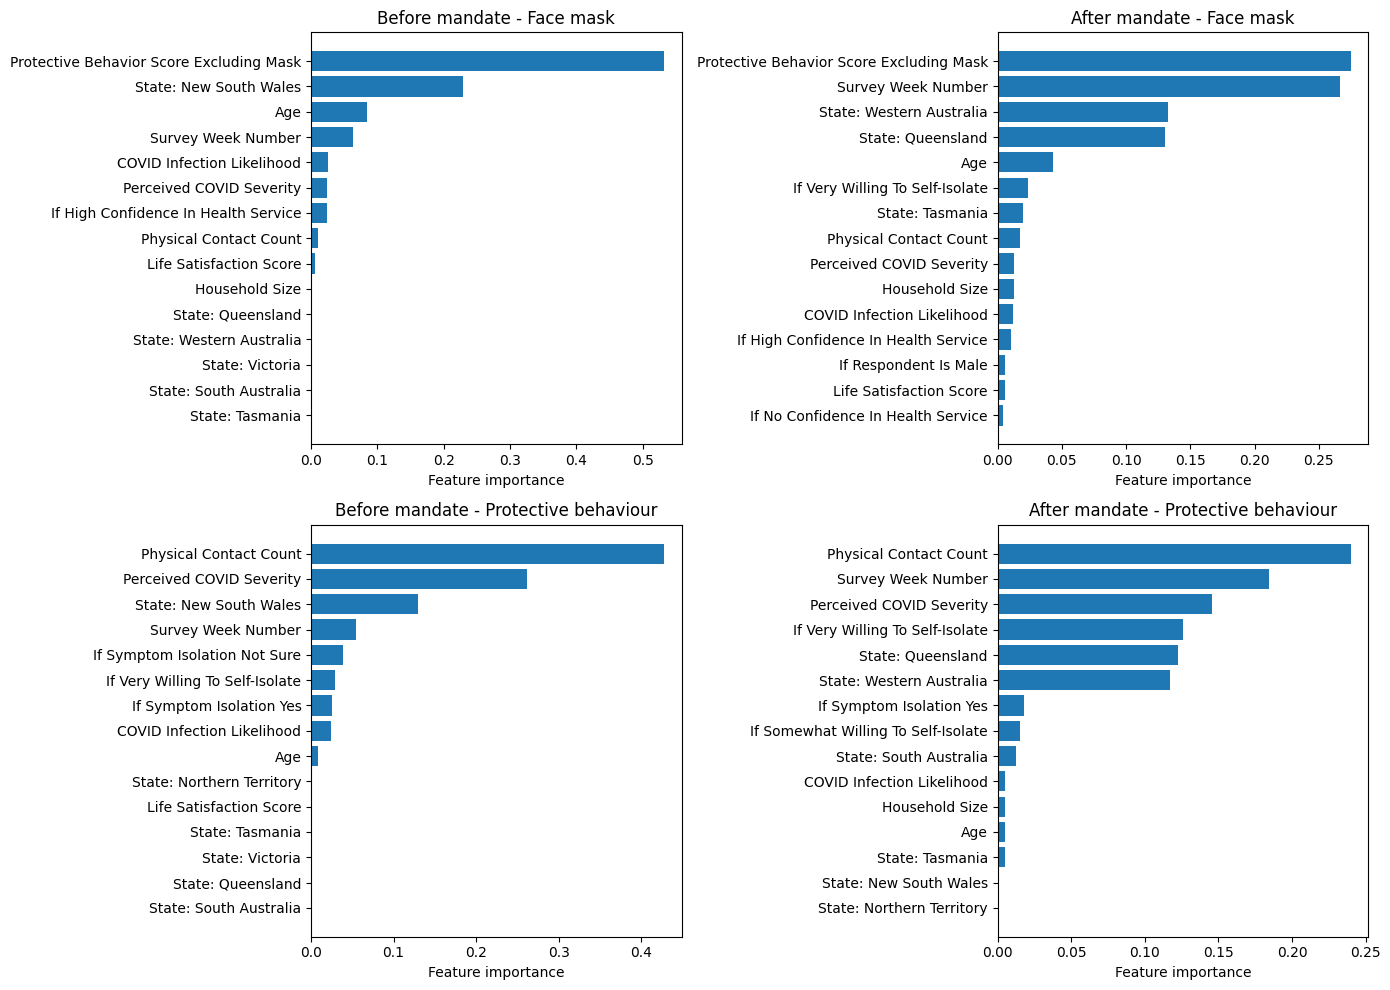

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, task in zip(axes, TASKS.keys()):
    importance_df = results[task]["importance_df"]
    top_df = importance_df.head(TOP_N_FEATURES).sort_values("importance", ascending=True)

    ax.barh(top_df["feature"], top_df["importance"])
    ax.set_title(TASKS[task])
    ax.set_xlabel("Feature importance")

plt.tight_layout()
plt.show()


### 4.9 All Model Indicators


In [13]:
metric_order = ["roc_auc", "f1", "accuracy", "precision", "recall"]
metric_names = {"roc_auc": "AUC",  "f1": "F1",  "accuracy": "Accuracy",  "precision": "Precision",  "recall": "Recall"}

task_order = list(TASKS.keys())

cv_tbl = (cv_summary_df.set_index("task").loc[task_order, ["label"] + metric_order].copy())

test_tbl = (test_summary_df.set_index("task").loc[task_order, metric_order].copy())

summary_table = pd.DataFrame({"Task": cv_tbl["label"].values})

for metric in metric_order:
    summary_table[f"CV {metric_names[metric]}"] = cv_tbl[metric].round(3).values
    summary_table[f"Test {metric_names[metric]}"] = test_tbl[metric].round(3).values

display(summary_table)


,Task,CV AUC,Test AUC,CV F1,Test F1,CV Accuracy,Test Accuracy,CV Precision,Test Precision,CV Recall,Test Recall
0,Before mandate - Face mask,0.819,0.830,0.607,0.630,0.734,0.755,0.516,0.546,0.736,0.745
1,After mandate - Face mask,0.859,0.869,0.873,0.877,0.823,0.829,0.883,0.890,0.863,0.865
2,Before mandate - Protective behaviour,0.740,0.734,0.686,0.676,0.682,0.675,0.667,0.663,0.706,0.690
3,After mandate - Protective behaviour,0.791,0.793,0.766,0.794,0.707,0.727,0.861,0.839,0.692,0.753
